# Get A Matrix from ODMR Data

This notebook takes ODMR data as input, fits it to extract the necessary parameters, and computes the linearized response matrix A and its pseudoinverse A+.

## Instructions for User:
1. Provide the path to your ODMR CSV file (e.g., 'ODMR_avg_99-6dBm_0mW.csv').
2. Manually identify and assign the four lower-frequency transitions to d1, d2, d3, d4 based on your experimental setup.
   - d1, d2 are typically below the plane, d3, d4 above.
   - Look at the fitted centers and assign them accordingly.
3. The notebook will output the A matrix and A+, with  MHz/nT and MHz/nT units respecively




In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.optimize import least_squares

from fit_functions import (
    normalize_signal,
    detect_8_transition_guesses,
    odmr_model_full,
    residuals_odmr_full,
)

from nv_hamiltonian import (
    transition_frequencies_mhz,
    compute_A_matrix_lower_transition,
)



In [5]:

# Frequency:
#   raw file frequency: Hz
#   fitted ODMR centers: MHz
#
# Magnetic field:
#   B0 and reconstructed fields: nT
#
# Gyromagnetic ratio:
#   Troise convention: gamma_e = 28.025 Hz/nT
#   Code convention:   gamma_e = 28.025e-6 MHz/nT
#
# A matrix:
#   A       = dnu/dB, units MHz/nT
#   A_plus  = dB/dnu, units nT/MHz
#
# Experimental lab frame:
#   x = magnet line, M1 -> M2
#   y = approximate wire direction / in-plane depth direction
#   z = optical axis / {100} surface normal

GAMMA_E_HZ_PER_NT = 28.025
GAMMA_E_MHZ_PER_NT = GAMMA_E_HZ_PER_NT * 1e-6

# z is the {100} surface normal.
# d1,d2 are the lower-z axes.
# d3,d4 are the upper-z axes.
NV_AXES = {
    "d1": np.array([-np.sqrt(2/3), 0.0, -1/np.sqrt(3)]),
    "d2": np.array([ np.sqrt(2/3), 0.0, -1/np.sqrt(3)]),
    "d3": np.array([0.0,  np.sqrt(2/3),  1/np.sqrt(3)]),
    "d4": np.array([0.0, -np.sqrt(2/3),  1/np.sqrt(3)]),
}

AXES_ORDER = ["d1", "d2", "d3", "d4"]

LAB_FRAME_NOTE = {
    "x": "magnet line M1-to-M2",
    "y": "approximate wire direction / in-plane depth",
    "z": "optical axis / diamond surface normal",
}

## 1. Fitting the ODMR

Loaded ODMR points: 1000
Frequency range: 2770.000 to 2969.800 MHz
Raw ODMR signal range: 0.065666 to 0.078267
Raw ODMR signal unit: whatever Pixel(95-95) stores; VOLTS.


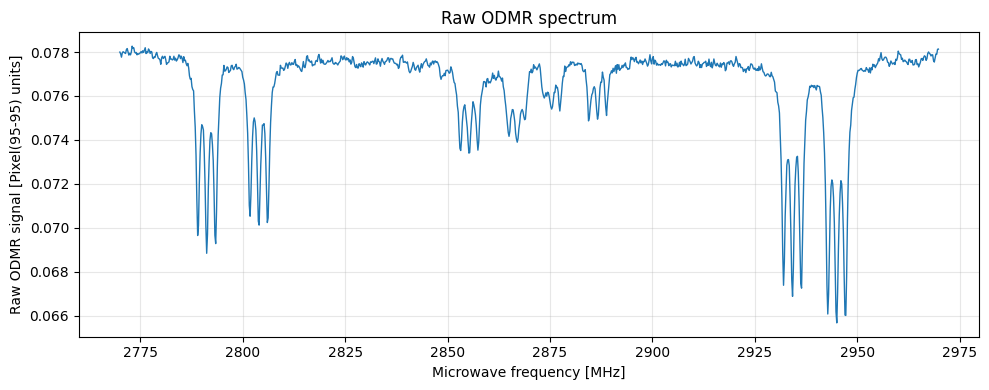

In [6]:
csv_path = "ODMR_avg_99-6dBm_0mW.csv" #put the path here- expects 2 columns

odmr_df = pd.read_csv(csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = "Frequency"
signal_col = "Pixel(95-95)"

f_hz = odmr_df[freq_col].to_numpy(dtype=float)
y_raw = odmr_df[signal_col].to_numpy(dtype=float)

sort_idx = np.argsort(f_hz)
f_hz = f_hz[sort_idx]
y_raw = y_raw[sort_idx]

# Convert frequency once.
f_mhz = f_hz / 1e6

print("Loaded ODMR points:", len(f_mhz))
print(f"Frequency range: {f_mhz.min():.3f} to {f_mhz.max():.3f} MHz")
print(f"Raw ODMR signal range: {y_raw.min():.6g} to {y_raw.max():.6g}")
print("Raw ODMR signal unit: whatever Pixel(95-95) stores; VOLTS.")

plt.figure(figsize=(10, 4))
plt.plot(f_mhz, y_raw, lw=1)
plt.xlabel("Microwave frequency [MHz]")
plt.ylabel("Raw ODMR signal [Pixel(95-95) units]")
plt.title("Raw ODMR spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Initial 8 center guesses [MHz]:
[2792.2 2805.  2854.2 2866.2 2874.6 2885.6 2935.2 2946. ]
p0 inside bounds: True
Both `ftol` and `xtol` termination conditions are satisfied.
Function evaluations 16, initial cost 1.7335e+01, final cost 8.9135e-02, first-order optimality 6.64e-06.


,transition_index,center_MHz,delta_hf_MHz,lorentz_fwhm_MHz,A_minus_norm,A_zero_norm,A_plus_norm
0,0,2791.205771,2.148610,1.030380,0.597031,0.637031,0.638792
1,1,2803.935023,2.171007,1.052441,0.526270,0.545889,0.563092
2,2,2855.262171,2.162743,1.279087,0.280061,0.275544,0.265299
3,3,2866.883056,1.966948,1.453627,0.221304,0.238803,0.150699
4,4,2875.480576,1.870623,1.074837,0.107012,0.151124,0.132956
5,5,2886.660938,2.112156,0.881934,0.198317,0.188135,0.161469
6,6,2934.173508,2.157099,1.113174,0.722041,0.745233,0.761567
7,7,2944.966220,2.153817,1.205617,0.807282,0.825066,0.868354


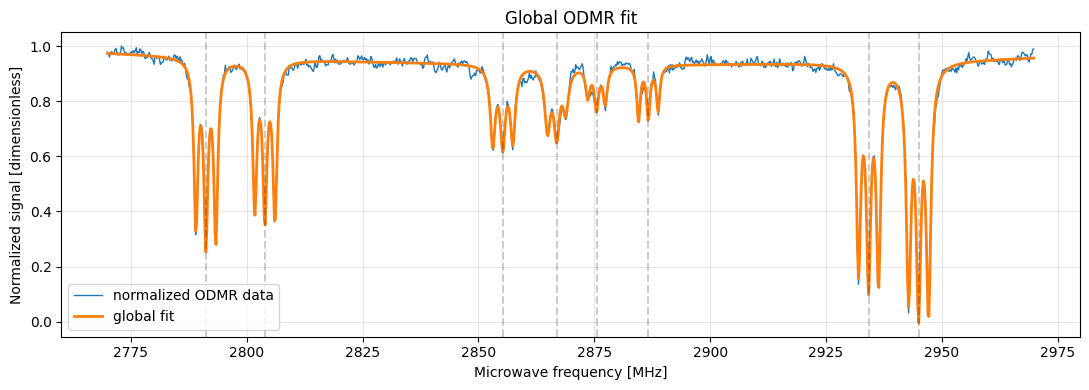

In [7]:
y_norm = normalize_signal(y_raw)

centers_guess, y_smooth, peak_idx, peak_prom = detect_8_transition_guesses(
    f_mhz,
    y_norm,
    smooth_window=21,
    polyorder=3,
    prominence=0.01,
)

centers_guess = np.asarray(centers_guess, dtype=float)

print("Initial 8 center guesses [MHz]:")
print(np.round(centers_guess, 4))

delta_hf_guess = np.full(8, 2.16, dtype=float)  # MHz, 14N hyperfine splitting
gamma_guess = np.full(8, 0.8, dtype=float)      # MHz, linewidth guess

amp_guess = []
for c0 in centers_guess:
    mask = np.abs(f_mhz - c0) < 1.5
    local_depth = np.max(1.0 - y_norm[mask]) if np.any(mask) else 0.15
    a = max(local_depth, 0.05)
    amp_guess.extend([0.35*a, 0.40*a, 0.35*a])

amp_guess = np.array(amp_guess, dtype=float)

p0 = np.concatenate([
    centers_guess,
    delta_hf_guess,
    gamma_guess,
    amp_guess,
    [0.0, 0.0, 1.0],   # quadratic baseline in normalized units
])

lb = np.concatenate([
    centers_guess - 3.0,
    np.full(8, 1.7),
    np.full(8, 0.15),
    np.zeros(24),
    [-1e-4, -1e-2, 0.7],
])

ub = np.concatenate([
    centers_guess + 3.0,
    np.full(8, 2.5),
    np.full(8, 2.5),
    np.full(24, 1.2),
    [1e-4, 1e-2, 1.2],
])

print("p0 inside bounds:", np.all(p0 >= lb) and np.all(p0 <= ub))

fit_odmr = least_squares(
    residuals_odmr_full,
    x0=p0,
    bounds=(lb, ub),
    args=(f_mhz, y_norm),
    method="trf",
    max_nfev=50000,
    verbose=1,
)

p_fit = fit_odmr.x
y_fit = odmr_model_full(f_mhz, p_fit)

centers_fit = np.asarray(p_fit[0:8], dtype=float)
delta_hf_fit = np.asarray(p_fit[8:16], dtype=float)
gamma_fit = np.asarray(p_fit[16:24], dtype=float)
amps_fit = np.asarray(p_fit[24:48], dtype=float).reshape(8, 3)

order = np.argsort(centers_fit)
centers_fit = centers_fit[order]
delta_hf_fit = delta_hf_fit[order]
gamma_fit = gamma_fit[order]
amps_fit = amps_fit[order]

fit_table = pd.DataFrame({
    "transition_index": np.arange(8),
    "center_MHz": centers_fit,
    "delta_hf_MHz": delta_hf_fit,
    "lorentz_fwhm_MHz": gamma_fit,
    "A_minus_norm": amps_fit[:, 0],
    "A_zero_norm": amps_fit[:, 1],
    "A_plus_norm": amps_fit[:, 2],
})

display(fit_table)

plt.figure(figsize=(11, 4))
plt.plot(f_mhz, y_norm, lw=1, label="normalized ODMR data")
plt.plot(f_mhz, y_fit, lw=2, label="global fit")

for c in centers_fit:
    plt.axvline(c, color="k", ls="--", alpha=0.2)

plt.xlabel("Microwave frequency [MHz]")
plt.ylabel("Normalized signal [dimensionless]")
plt.title("Global ODMR fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:

#Current convention:
#lower side of ODMR:
#       d1, d2, d3, d4
# If your ODMR dip-assignment plot says otherwise, change these indices

lower_index = {
    "d1": 0,
    "d2": 1,
    "d3": 2,
    "d4": 3,
}

# Pair lower and upper transitions.
pairs = {}

for axis in AXES_ORDER:
    i_low = lower_index[axis]
    i_up = 7 - i_low

    f_lower = centers_fit[i_low]
    f_upper = centers_fit[i_up]

    if f_upper <= f_lower:
        raise ValueError(f"Bad pairing for {axis}: upper <= lower")

    pairs[axis] = (f_lower, f_upper)

pair_rows = []
for axis in AXES_ORDER:
    f_l, f_u = pairs[axis]
    pair_rows.append({
        "axis": axis,
        "f_lower_MHz": f_l,
        "f_upper_MHz": f_u,
        "pair_center_MHz": 0.5 * (f_l + f_u),
        "splitting_MHz": f_u - f_l,
        "abs_projection_nT_linear_guess": (f_u - f_l) / (2 * GAMMA_E_MHZ_PER_NT),
    })

pairs_df = pd.DataFrame(pair_rows)
display(pairs_df)

f_lower_meas_mhz = np.array([pairs[ax][0] for ax in AXES_ORDER], dtype=float)

print("Tracked lower-transition frequencies [MHz], order d1,d2,d3,d4:")
print(f_lower_meas_mhz)

,axis,f_lower_MHz,f_upper_MHz,pair_center_MHz,splitting_MHz,abs_projection_nT_linear_guess
0,d1,2791.205771,2944.966220,2868.085996,153.760448,2.743273e+06
1,d2,2803.935023,2934.173508,2869.054265,130.238484,2.323613e+06
2,d3,2855.262171,2886.660938,2870.961555,31.398766,5.601921e+05
3,d4,2866.883056,2875.480576,2871.181816,8.597521,1.533902e+05


Tracked lower-transition frequencies [MHz], order d1,d2,d3,d4:
[2791.20577148 2803.93502334 2855.26217136 2866.88305566]


## 2. Identify operating point, get Bo, D and Mz

In [9]:
# Initial D estimate from pair centers.
D0_guess_mhz = pairs_df["pair_center_MHz"].mean()

# Static axis-dependent offsets in MHz.
Mz0_guess_mhz = {
    row["axis"]: row["pair_center_MHz"] - D0_guess_mhz
    for _, row in pairs_df.iterrows()
}

print(f"Initial D guess = {D0_guess_mhz:.6f} MHz")
print("Initial Mz guesses [MHz]:")
for axis in AXES_ORDER:
    print(f"  {axis}: {Mz0_guess_mhz[axis]: .6f}")

# Initial B0 estimate from axial Zeeman approximation.
# This only gives a starting point for the Hamiltonian fit.
N = np.vstack([NV_AXES[axis] for axis in AXES_ORDER])
proj_abs_nT = pairs_df["abs_projection_nT_linear_guess"].to_numpy(dtype=float)

best = None

for signs in product([-1.0, 1.0], repeat=4):
    projected_field_nT = np.array(signs, dtype=float) * proj_abs_nT

    B_candidate_nT, *_ = np.linalg.lstsq(N, projected_field_nT, rcond=None)
    residual = projected_field_nT - N @ B_candidate_nT
    ssr = float(residual @ residual)

    if best is None or ssr < best["SSR"]:
        best = {
            "signs": signs,
            "B0_nT": B_candidate_nT,
            "SSR": ssr,
        }

B0_guess_nT = best["B0_nT"]

print("Best sign pattern:", best["signs"])
print(
    "Initial B0 guess [nT] = "
    f"({B0_guess_nT[0]:.3f}, {B0_guess_nT[1]:.3f}, {B0_guess_nT[2]:.3f})"
)
print(f"Initial |B0| = {np.linalg.norm(B0_guess_nT):.3f} nT")
print(f"Initial |B0| = {np.linalg.norm(B0_guess_nT)/1e6:.6f} mT")

Initial D guess = 2869.820908 MHz
Initial Mz guesses [MHz]:
  d1: -1.734912
  d2: -0.766642
  d3:  1.140647
  d4:  1.360908
Best sign pattern: (-1.0, 1.0, 1.0, -1.0)
Initial B0 guess [nT] = (3102821.019, 436978.120, 357868.657)
Initial |B0| = 3153810.098 nT
Initial |B0| = 3.153810 mT


In [10]:
#improve the guess by fitting hamiltonian

def residuals_operating_point(theta):
    """
    theta =
        [Bx_nT, By_nT, Bz_nT, D_MHz, Mz_d1_MHz, Mz_d2_MHz, Mz_d3_MHz, Mz_d4_MHz]

    Residuals:
        predicted lower/upper transition frequencies minus measured lower/upper
        transition frequencies.

    Units:
        B: nT
        D, Mz, residuals: MHz
    """
    B0_nT = np.array(theta[0:3], dtype=float)
    D_mhz = theta[3]

    Mz_map_mhz = {
        "d1": theta[4],
        "d2": theta[5],
        "d3": theta[6],
        "d4": theta[7],
    }

    res = []

    for axis in AXES_ORDER:
        f_lower_pred, f_upper_pred = transition_frequencies_mhz(
            B0_nT,
            D_mhz,
            Mz_map_mhz[axis],
            axis,
            NV_AXES,
            GAMMA_E_MHZ_PER_NT,
        )

        f_lower_meas, f_upper_meas = pairs[axis]

        res.append(f_lower_pred - f_lower_meas)
        res.append(f_upper_pred - f_upper_meas)

    return np.array(res, dtype=float)


theta0 = np.array([
    B0_guess_nT[0],
    B0_guess_nT[1],
    B0_guess_nT[2],
    D0_guess_mhz,
    Mz0_guess_mhz["d1"],
    Mz0_guess_mhz["d2"],
    Mz0_guess_mhz["d3"],
    Mz0_guess_mhz["d4"],
], dtype=float)

# Bounds:
#   B range ±50 mT = ±50e6 nT
#   D range broad enough for room-temperature ODMR around 2870 MHz
#   Mz range ±20 MHz
lb = np.array([
    -50e6, -50e6, -50e6,
    2800.0,
    -20.0, -20.0, -20.0, -20.0,
], dtype=float)

ub = np.array([
     50e6,  50e6,  50e6,
    2940.0,
     20.0,  20.0,  20.0,  20.0,
], dtype=float)

fit_op = least_squares(
    residuals_operating_point,
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=20000,
    verbose=1,
)

theta_fit = fit_op.x

B0_fit_nT = theta_fit[0:3]
D_fit_mhz = theta_fit[3]

Mz_fit_mhz = {
    "d1": theta_fit[4],
    "d2": theta_fit[5],
    "d3": theta_fit[6],
    "d4": theta_fit[7],
}

print("Refined operating point")
print("------------------------")
print(f"B0 [nT] = ({B0_fit_nT[0]:.3f}, {B0_fit_nT[1]:.3f}, {B0_fit_nT[2]:.3f})")
print(f"|B0| [nT] = {np.linalg.norm(B0_fit_nT):.3f}")
print(f"|B0| [mT] = {np.linalg.norm(B0_fit_nT)/1e6:.6f}")
print(f"D [MHz] = {D_fit_mhz:.6f}")

print("Mz [MHz]:")
for axis in AXES_ORDER:
    print(f"  {axis}: {Mz_fit_mhz[axis]: .6f}")

print(f"Residual norm [MHz] = {np.linalg.norm(fit_op.fun):.6e}")

# Show predicted vs measured transition frequencies.
check_rows = []
for axis in AXES_ORDER:
    f_l_pred, f_u_pred = transition_frequencies_mhz(
        B0_fit_nT,
        D_fit_mhz,
        Mz_fit_mhz[axis],
        axis,
        NV_AXES,
        GAMMA_E_MHZ_PER_NT,
    )

    f_l_meas, f_u_meas = pairs[axis]

    check_rows.append({
        "axis": axis,
        "f_lower_meas_MHz": f_l_meas,
        "f_lower_pred_MHz": f_l_pred,
        "lower_error_kHz": 1e3 * (f_l_pred - f_l_meas),
        "f_upper_meas_MHz": f_u_meas,
        "f_upper_pred_MHz": f_u_pred,
        "upper_error_kHz": 1e3 * (f_u_pred - f_u_meas),
    })

check_df = pd.DataFrame(check_rows)
display(check_df)

`xtol` termination condition is satisfied.
Function evaluations 11, initial cost 3.6653e+01, final cost 8.5198e-03, first-order optimality 1.80e-03.
Refined operating point
------------------------
B0 [nT] = (3103253.510, 431050.649, 360537.464)
|B0| [nT] = 3153723.873
|B0| [mT] = 3.153724
D [MHz] = 2867.238043
Mz [MHz]:
  d1: -0.150075
  d2: -0.048297
  d3: -0.231023
  d4: -0.130711
Residual norm [MHz] = 1.305359e-01


,axis,f_lower_meas_MHz,f_lower_pred_MHz,lower_error_kHz,f_upper_meas_MHz,f_upper_pred_MHz,upper_error_kHz
0,d1,2791.205771,2791.250978,45.206239,2944.966220,2944.921014,-45.205891
1,d2,2803.935023,2803.889379,-45.644560,2934.173508,2934.219153,45.645075
2,d3,2855.262171,2855.216472,-45.699454,2886.660938,2886.706641,45.703158
3,d4,2866.883056,2866.931049,47.993366,2875.480576,2875.432566,-48.010021


## 3. calculate A around the base point

In [11]:
# 1000 nT = 1 microtesla.
# This is small relative to mT-scale B0 and convenient numerically.
dB_step_nT = 1000.0

A_MHz_per_nT = compute_A_matrix_lower_transition(
    B0_nT=B0_fit_nT,
    D_mhz=D_fit_mhz,
    Mz_map_mhz=Mz_fit_mhz,
    axes_order=AXES_ORDER,
    nv_axes=NV_AXES,
    gamma_e_mhz_per_nT=GAMMA_E_MHZ_PER_NT,
    dB_step_nT=dB_step_nT,
)

Aplus_nT_per_MHz = np.linalg.pinv(A_MHz_per_nT)

A_df = pd.DataFrame(
    A_MHz_per_nT,
    index=AXES_ORDER,
    columns=["dnu_dBx_MHz_per_nT", "dnu_dBy_MHz_per_nT", "dnu_dBz_MHz_per_nT"],
)

Aplus_df = pd.DataFrame(
    Aplus_nT_per_MHz,
    index=["Bx_nT", "By_nT", "Bz_nT"],
    columns=[f"dnu_{axis}_MHz" for axis in AXES_ORDER],
)

print("A matrix units: MHz/nT")
display(A_df)

print("A+ pseudoinverse units: nT/MHz")
display(Aplus_df)

# Also display the more familiar MHz/mT and mT/MHz versions for comparison.
A_MHz_per_mT = 1e6 * A_MHz_per_nT
Aplus_mT_per_MHz = 1e-6 * Aplus_nT_per_MHz

A_mT_display = pd.DataFrame(
    A_MHz_per_mT,
    index=AXES_ORDER,
    columns=["dnu_dBx_MHz_per_mT", "dnu_dBy_MHz_per_mT", "dnu_dBz_MHz_per_mT"],
)

Aplus_mT_display = pd.DataFrame(
    Aplus_mT_per_MHz,
    index=["Bx_mT", "By_mT", "Bz_mT"],
    columns=[f"dnu_{axis}_MHz" for axis in AXES_ORDER],
)

print("Same A matrix shown as MHz/mT:")
display(A_mT_display)

print("Same A+ shown as mT/MHz:")
display(Aplus_mT_display)

svals = np.linalg.svd(A_MHz_per_nT, compute_uv=False)
cond_A = svals.max() / svals.min()
print(f"Condition number of A = {cond_A:.3f}")

A matrix units: MHz/nT


,dnu_dBx_MHz_per_nT,dnu_dBy_MHz_per_nT,dnu_dBz_MHz_per_nT
d1,-0.000022,3.569848e-07,-0.000017
d2,-0.000022,3.556605e-07,0.000018
d3,0.000002,-2.281216e-05,-0.000016
d4,0.000002,-2.144254e-05,0.000016


A+ pseudoinverse units: nT/MHz


,dnu_d1_MHz,dnu_d2_MHz,dnu_d3_MHz,dnu_d4_MHz
Bx_nT,-22954.201722,-22530.378496,-407.550787,-322.273020
By_nT,-1968.013835,-2925.969295,-22872.279877,-22384.337267
Bz_nT,-15620.222190,15784.051464,-13867.328231,14754.846590


Same A matrix shown as MHz/mT:


,dnu_dBx_MHz_per_mT,dnu_dBy_MHz_per_mT,dnu_dBz_MHz_per_mT
d1,-22.163095,0.356985,-17.190375
d2,-21.881906,0.355661,17.580870
d3,2.479331,-22.812164,-16.086104
d4,2.275480,-21.442538,15.650036


Same A+ shown as mT/MHz:


,dnu_d1_MHz,dnu_d2_MHz,dnu_d3_MHz,dnu_d4_MHz
Bx_mT,-0.022954,-0.022530,-0.000408,-0.000322
By_mT,-0.001968,-0.002926,-0.022872,-0.022384
Bz_mT,-0.015620,0.015784,-0.013867,0.014755


Condition number of A = 1.149


## 4. Extract local ODMR slopes for pulse reconstruction

The A-matrix converts frequency shifts into magnetic-field components.  
For pulse data, we also need the local ODMR slope for each tracked lower transitins

In [12]:
# ============================================================
# 4. Extract local ODMR slopes for pulse reconstruction
# ============================================================
# Purpose:
#   Convert pulse voltage changes into ODMR frequency shifts:
#
#       delta_nu [MHz] = delta_V [V] / slope [V/MHz]
#
# Important:
#   - f_mhz comes from the ODMR file and is in MHz.
#   - y_raw is the raw ODMR signal and is assumed to be in V.
#   - The windows below should lie on the approximately linear
#     flank of each tracked lower-frequency ODMR transition.
#

manual_windows_mhz = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2863.9, 2864.8),
}

slope_rows = []

for axis in AXES_ORDER:
    f_min, f_max = manual_windows_mhz[axis]
    center_mhz = pairs[axis][0]   # lower-transition center from the ODMR fit

    mask = (f_mhz >= f_min) & (f_mhz <= f_max)

    f_fit = f_mhz[mask]
    V_fit = y_raw[mask]

    if len(f_fit) < 3:
        raise ValueError(
            f"{axis}: too few points in slope window "
            f"{f_min} to {f_max} MHz. Choose a wider window."
        )

    coeffs = np.polyfit(f_fit, V_fit, deg=1)

    slope_V_per_MHz = coeffs[0]
    intercept_V = coeffs[1]

    V_line = slope_V_per_MHz * f_fit + intercept_V
    residuals_V = V_fit - V_line
    rms_residual_V = np.sqrt(np.mean(residuals_V**2))

    slope_rows.append({
        "axis": axis,
        "center_MHz": center_mhz,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_V_per_MHz": slope_V_per_MHz,
        "intercept_V": intercept_V,
        "n_points": int(len(f_fit)),
        "rms_residual_V": rms_residual_V,
    })

slopes_df = pd.DataFrame(slope_rows)

display(slopes_df)

slopes_V_per_MHz = slopes_df["slope_V_per_MHz"].to_numpy(dtype=float)

print("Final selected ODMR slopes for pulse conversion:")
print("Units: V/MHz")
for axis, slope in zip(AXES_ORDER, slopes_V_per_MHz):
    print(f"{axis}: {slope:.8g} V/MHz")

,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_V_per_MHz,intercept_V,n_points,rms_residual_V
0,d1,2791.205771,2788.0,2788.9,-0.005998,16.798954,5,0.000360
1,d2,2803.935023,2801.0,2801.7,-0.006857,19.283244,4,0.000266
2,d3,2855.262171,2852.0,2853.0,-0.002656,7.651833,6,0.000199
3,d4,2866.883056,2863.9,2864.8,-0.001930,5.603410,5,0.000025


Final selected ODMR slopes for pulse conversion:
Units: V/MHz
d1: -0.005998 V/MHz
d2: -0.0068575 V/MHz
d3: -0.0026561429 V/MHz
d4: -0.00193 V/MHz


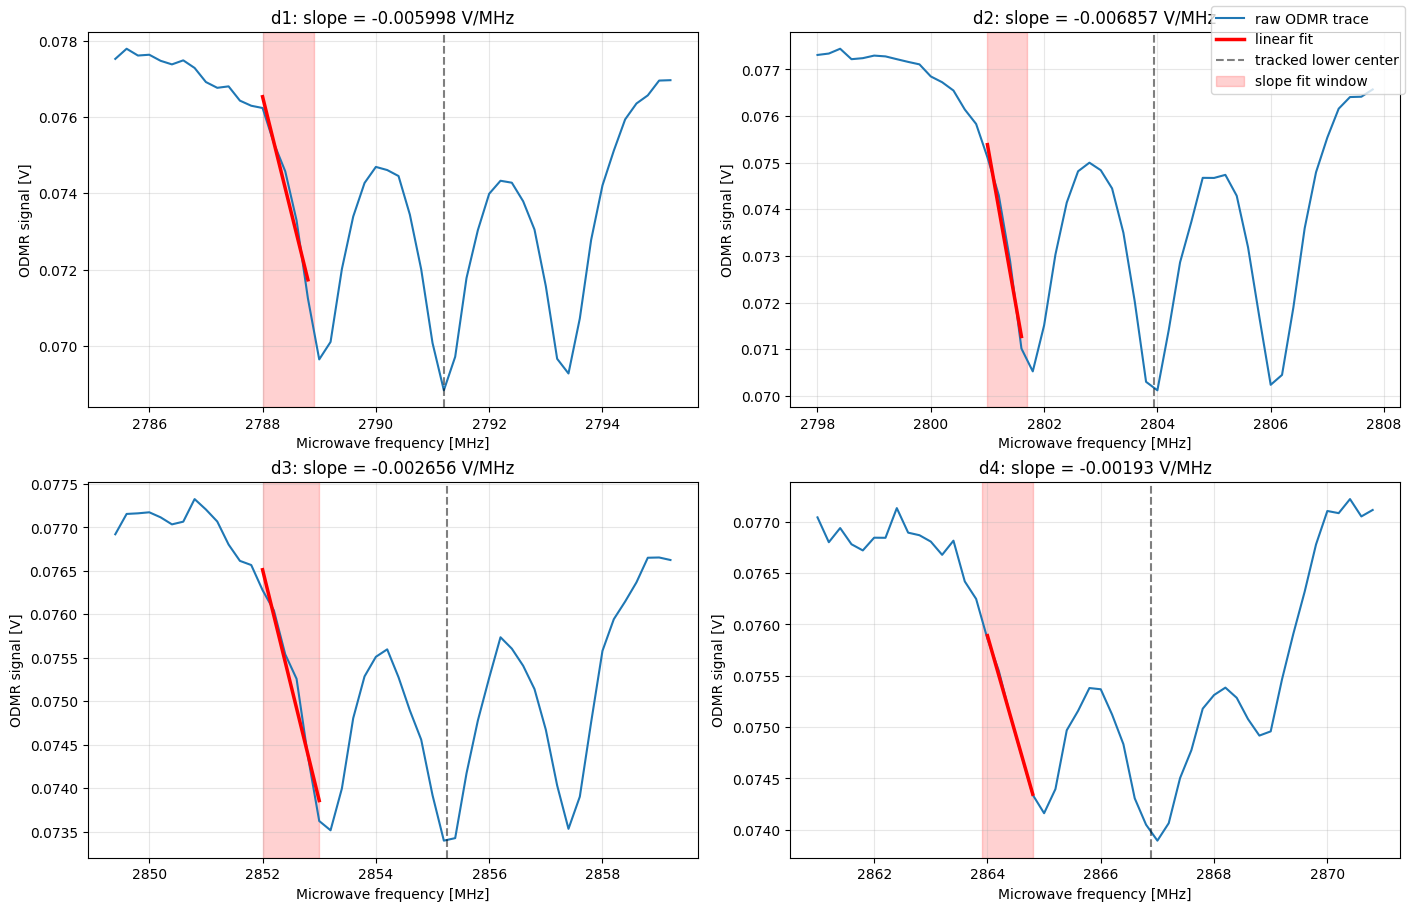

In [13]:
# ============================================================
# Plot ODMR slope windows and local linear fits
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.ravel()

left_span_mhz = 6.0
right_span_mhz = 4.0

for i, axis in enumerate(AXES_ORDER):
    ax = axes[i]

    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_V_per_MHz"]
    intercept = slopes_df.loc[i, "intercept_V"]

    zoom_mask = (f_mhz >= center - left_span_mhz) & (f_mhz <= center + right_span_mhz)
    fit_mask = (f_mhz >= f_min) & (f_mhz <= f_max)

    f_fit = f_mhz[fit_mask]
    V_line = slope * f_fit + intercept

    ax.plot(
        f_mhz[zoom_mask],
        y_raw[zoom_mask],
        lw=1.5,
        label="raw ODMR trace"
    )

    ax.plot(
        f_fit,
        V_line,
        color="red",
        lw=2.5,
        label="linear fit"
    )

    ax.axvline(
        center,
        color="black",
        ls="--",
        alpha=0.5,
        label="tracked lower center" if i == 0 else None
    )

    ax.axvspan(
        f_min,
        f_max,
        color="red",
        alpha=0.18,
        label="slope fit window" if i == 0 else None
    )

    ax.set_title(f"{axis}: slope = {slope:.4g} V/MHz")
    ax.set_xlabel("Microwave frequency [MHz]")
    ax.set_ylabel("ODMR signal [V]")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.show()

In [14]:
# 5. Save full calibration for pulse reconstruction

rows = []

rows.append({
    "group": "metadata",
    "row": "gamma_e",
    "col": "",
    "value": GAMMA_E_HZ_PER_NT,
    "unit": "Hz/nT",
    "note": "Troise convention for electron gyromagnetic ratio"
})

rows.append({
    "group": "metadata",
    "row": "gamma_e",
    "col": "",
    "value": GAMMA_E_MHZ_PER_NT,
    "unit": "MHz/nT",
    "note": "Code convention used in Hamiltonian"
})

rows.append({
    "group": "metadata",
    "row": "axes_order",
    "col": "",
    "value": np.nan,
    "unit": "",
    "note": ",".join(AXES_ORDER)
})

rows.append({
    "group": "metadata",
    "row": "frequency_unit",
    "col": "",
    "value": np.nan,
    "unit": "MHz",
    "note": "ODMR fit centers and frequency shifts are in MHz"
})

rows.append({
    "group": "metadata",
    "row": "field_unit",
    "col": "",
    "value": np.nan,
    "unit": "nT",
    "note": "B0 and reconstructed pulse fields are in nT"
})

# ----------------------------
# Operating point
# ----------------------------
for comp, value in zip(["Bx", "By", "Bz"], B0_fit_nT):
    rows.append({
        "group": "B0",
        "row": comp,
        "col": "",
        "value": value,
        "unit": "nT",
        "note": "Fitted static bias-field component"
    })

rows.append({
    "group": "B0",
    "row": "B_abs",
    "col": "",
    "value": np.linalg.norm(B0_fit_nT),
    "unit": "nT",
    "note": "Magnitude of fitted static bias field"
})

rows.append({
    "group": "D",
    "row": "",
    "col": "",
    "value": D_fit_mhz,
    "unit": "MHz",
    "note": "Fitted zero-field splitting"
})

for axis in AXES_ORDER:
    rows.append({
        "group": "Mz",
        "row": axis,
        "col": "",
        "value": Mz_fit_mhz[axis],
        "unit": "MHz",
        "note": "Axis-dependent static shift used in Hamiltonian fit"
    })

# ----------------------------
# ODMR transition centers
# ----------------------------
for axis in AXES_ORDER:
    f_lower, f_upper = pairs[axis]

    rows.append({
        "group": "lower_center",
        "row": axis,
        "col": "",
        "value": f_lower,
        "unit": "MHz",
        "note": "Tracked lower-transition ODMR center"
    })

    rows.append({
        "group": "upper_center",
        "row": axis,
        "col": "",
        "value": f_upper,
        "unit": "MHz",
        "note": "Paired upper-transition ODMR center"
    })

    rows.append({
        "group": "pair_center",
        "row": axis,
        "col": "",
        "value": 0.5 * (f_lower + f_upper),
        "unit": "MHz",
        "note": "Mean of lower and upper transition"
    })

    rows.append({
        "group": "splitting",
        "row": axis,
        "col": "",
        "value": f_upper - f_lower,
        "unit": "MHz",
        "note": "Upper minus lower transition frequency"
    })

# ----------------------------
# ODMR local slopes for pulse conversion
# ----------------------------
for _, r in slopes_df.iterrows():
    axis = r["axis"]

    rows.append({
        "group": "slope",
        "row": axis,
        "col": "slope",
        "value": float(r["slope_V_per_MHz"]),
        "unit": "V/MHz",
        "note": "Local ODMR slope used for delta_V to delta_nu conversion"
    })

    rows.append({
        "group": "slope_window",
        "row": axis,
        "col": "fit_start",
        "value": float(r["fit_start_MHz"]),
        "unit": "MHz",
        "note": "Start of local ODMR slope-fit window"
    })

    rows.append({
        "group": "slope_window",
        "row": axis,
        "col": "fit_end",
        "value": float(r["fit_end_MHz"]),
        "unit": "MHz",
        "note": "End of local ODMR slope-fit window"
    })

    rows.append({
        "group": "slope_intercept",
        "row": axis,
        "col": "intercept",
        "value": float(r["intercept_V"]),
        "unit": "V",
        "note": "Intercept of local ODMR slope fit"
    })

    rows.append({
        "group": "slope_fit_quality",
        "row": axis,
        "col": "rms_residual",
        "value": float(r["rms_residual_V"]),
        "unit": "V",
        "note": "RMS residual of local linear slope fit"
    })

    rows.append({
        "group": "slope_fit_quality",
        "row": axis,
        "col": "n_points",
        "value": float(r["n_points"]),
        "unit": "count",
        "note": "Number of points used in local slope fit"
    })

# ----------------------------
# A matrix: frequency response
# ----------------------------
for i, axis in enumerate(AXES_ORDER):
    for j, comp in enumerate(["Bx", "By", "Bz"]):
        rows.append({
            "group": "A",
            "row": axis,
            "col": comp,
            "value": A_MHz_per_nT[i, j],
            "unit": "MHz/nT",
            "note": "Lower-transition frequency response dnu/dB"
        })

# ----------------------------
# A plus: inverse reconstruction matrix
# ----------------------------
for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, axis in enumerate(AXES_ORDER):
        rows.append({
            "group": "A_plus",
            "row": comp,
            "col": axis,
            "value": Aplus_nT_per_MHz[i, j],
            "unit": "nT/MHz",
            "note": "Pseudoinverse converting frequency shifts to B-field"
        })


Aplus_mT_per_MHz = 1e-6 * Aplus_nT_per_MHz

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, axis in enumerate(AXES_ORDER):
        rows.append({
            "group": "A_plus_mT",
            "row": comp,
            "col": axis,
            "value": Aplus_mT_per_MHz[i, j],
            "unit": "mT/MHz",
            "note": "Same A_plus shown in mT/MHz for comparison"
        })


results_A_df = pd.DataFrame(rows)
results_A_df.to_csv("A_results.csv", index=False)

display(results_A_df)

print("Saved full calibration to A_results.csv")
print()
print("Important saved units:")
print("  slope:   V/MHz")
print("  A:       MHz/nT")
print("  A_plus:  nT/MHz")
print()
print("Pulse notebook should use:")
print("  delta_nu_MHz = delta_V / slope_V_per_MHz")
print("  B_nT = Aplus_nT_per_MHz @ delta_nu_MHz")

,group,row,col,value,unit,note
0,metadata,gamma_e,,28.025000,Hz/nT,Troise convention for electron gyromagnetic ratio
1,metadata,gamma_e,,0.000028,MHz/nT,Code convention used in Hamiltonian
2,metadata,axes_order,,NaN,,"d1,d2,d3,d4"
3,metadata,frequency_unit,,NaN,MHz,ODMR fit centers and frequency shifts are in MHz
4,metadata,field_unit,,NaN,nT,B0 and reconstructed pulse fields are in nT
...,...,...,...,...,...,...
85,A_plus_mT,By,d4,-0.022384,mT/MHz,Same A_plus shown in mT/MHz for comparison
86,A_plus_mT,Bz,d1,-0.015620,mT/MHz,Same A_plus shown in mT/MHz for comparison
87,A_plus_mT,Bz,d2,0.015784,mT/MHz,Same A_plus shown in mT/MHz for comparison
88,A_plus_mT,Bz,d3,-0.013867,mT/MHz,Same A_plus shown in mT/MHz for comparison


Saved full calibration to A_results.csv

Important saved units:
  slope:   V/MHz
  A:       MHz/nT
  A_plus:  nT/MHz

Pulse notebook should use:
  delta_nu_MHz = delta_V / slope_V_per_MHz
  B_nT = Aplus_nT_per_MHz @ delta_nu_MHz
